In [1]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END


In [2]:
class AgentState(TypedDict):
    score: int
    message: str

In [3]:
def check_score(state: AgentState) -> dict:
    print("Checking score")

    return {
        "message": f"Your score is {state.get("score")}"
    }

In [4]:
def passed_node(state: AgentState) -> dict:
    print(f"passed_node-Current State: {state}")
    return {
        "message": "Congratulations! You passed your exam"
    }

In [5]:
def failed_node(state: AgentState) -> dict:
    print(f"failed_node-Current State: {state}")
    return {
        "message": "Sorry! You failed your exam. Try again"
    }

In [6]:
def route_by_score(state: AgentState) -> Literal["passed", "failed"]:
    print(f"route_by_score-Current State: {state}")
    if state.get('score') >= 60:
        return "passed"
    return "failed"


In [7]:
graph = StateGraph(AgentState)

In [8]:
graph.add_node("check_score", check_score)
graph.add_node("passed_node", passed_node)
graph.add_node("failed_node", failed_node)


In [9]:
# graph.set_entry_point()
# graph.set_finish_point()
graph.add_edge(START, "check_score")
graph.add_conditional_edges(
    "check_score",
    route_by_score,
    {
        "passed": "passed_node",
        "failed": "failed_node"
    }
)
graph.add_edge("passed_node", END)
graph.add_edge("failed_node", END)

In [10]:
workflow = graph.compile()

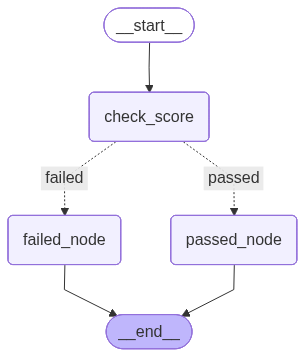

In [11]:
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))

In [12]:
result = workflow.invoke(
    {
        "score": 89,
        "message": "This is a user message"
    }
)

Checking score
route_by_score-Current State: {'score': 89, 'message': 'Your score is 89'}
passed_node-Current State: {'score': 89, 'message': 'Your score is 89'}


In [13]:
print(result)

{'score': 89, 'message': 'Congratulations! You passed your exam'}
